<a href="https://colab.research.google.com/github/Nakib-Nasrullah/Dengue_Research/blob/main/dengue_my_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets/Dengue_final_dataset_updated.csv')
print("Dataset loaded successfully!!")
print(f"\n Dataset shape: {df.shape}")

Mounted at /content/drive
Dataset loaded successfully!!

 Dataset shape: (23360, 23)


In [4]:
# Ensure date sorted
df = df.sort_values("Date").reset_index(drop=True)

# Fill missing dengue cases with 0
df["Dengue_Cases"] = df["Dengue_case"].fillna(0)

In [5]:
MAX_LAG = 21

for k in range(1, MAX_LAG + 1):
    df[f"D_lag_{k}"] = df["Dengue_Cases"].shift(k)

In [6]:
df = df.dropna().reset_index(drop=True)

# ***Learn Optimal Infectious Pressure Weights***

Instead of manually assigning weights, we let the model learn them.

Use LASSO (important for selecting meaningful lags)

In [7]:
from sklearn.linear_model import LassoCV

# Prepare X (lagged dengue)
X_ip = df[[f"D_lag_{k}" for k in range(1, MAX_LAG + 1)]]

# Target
y = df["Dengue_Cases"]

# Fit LASSO
lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X_ip, y)

# Extract weights
weights = lasso.coef_

# Display weights
ip_weights = pd.DataFrame({
    "Lag": range(1, MAX_LAG + 1),
    "Weight": weights
})

print(ip_weights)

    Lag    Weight
0     1  0.030291
1     2  0.011721
2     3  0.020740
3     4  0.028824
4     5  0.029851
5     6  0.018407
6     7  0.021238
7     8  0.015428
8     9  0.043381
9    10  0.025345
10   11  0.028469
11   12  0.021319
12   13  0.024707
13   14  0.033916
14   15  0.019502
15   16  0.014726
16   17  0.026705
17   18  0.030256
18   19  0.023581
19   20  0.014521
20   21  0.027460


# ***Compute Infectious Pressure*** (Data-Driven)

In [8]:
df["IP"] = 0

for k in range(1, MAX_LAG + 1):
    df["IP"] += weights[k-1] * df[f"D_lag_{k}"]

# Log transform (important)
df["IP_log"] = np.log1p(df["IP"])


# ***Create Rainfall Lag Features***

We use biologically meaningful lags: 7–35 days

In [9]:
RAIN_LAGS = range(7, 36)

for k in RAIN_LAGS:
    df[f"Rain_lag_{k}"] = df["Rainfall"].shift(k)

Create aggregated rainfall windows

In [10]:
# Main window (14–28 days)
df["Rain_mean_14_28"] = df[[f"Rain_lag_{k}" for k in range(14, 29)]].mean(axis=1)
df["Rain_sum_14_28"] = df[[f"Rain_lag_{k}" for k in range(14, 29)]].sum(axis=1)

# Early window
df["Rain_mean_7_14"] = df[[f"Rain_lag_{k}" for k in range(7, 15)]].mean(axis=1)

# Late window
df["Rain_mean_28_35"] = df[[f"Rain_lag_{k}" for k in range(28, 36)]].mean(axis=1)

# ***Temperature Lag Features***

In [13]:
TEMP_LAGS = range(7, 36)

for k in TEMP_LAGS:
    df[f"Temp_lag_{k}"] = df["Avg_Temp"].shift(k)


In [12]:
print(df.columns)

Index(['Date', 'District', 'Max_Temp', 'Min_Temp', 'Avg_Temp', 'Humidity',
       'Rainfall', 'Rainfall_Lag_7', 'Rainfall_Lag_14', 'Rainfall_Lag_21',
       'Rainfall_Lag_30', 'Temp_Lag_7', 'Temp_Lag_14', 'Temp_Lag_21',
       'Temp_Lag_30', 'Humidity_Lag_7', 'Humidity_Lag_14', 'Humidity_Lag_21',
       'Humidity_Lag_30', 'Dengue_Lag_7', 'Population_Density', 'Urban_Index',
       'Dengue_case', 'Dengue_Cases', 'D_lag_1', 'D_lag_2', 'D_lag_3',
       'D_lag_4', 'D_lag_5', 'D_lag_6', 'D_lag_7', 'D_lag_8', 'D_lag_9',
       'D_lag_10', 'D_lag_11', 'D_lag_12', 'D_lag_13', 'D_lag_14', 'D_lag_15',
       'D_lag_16', 'D_lag_17', 'D_lag_18', 'D_lag_19', 'D_lag_20', 'D_lag_21',
       'IP', 'IP_log', 'Rain_lag_7', 'Rain_lag_8', 'Rain_lag_9', 'Rain_lag_10',
       'Rain_lag_11', 'Rain_lag_12', 'Rain_lag_13', 'Rain_lag_14',
       'Rain_lag_15', 'Rain_lag_16', 'Rain_lag_17', 'Rain_lag_18',
       'Rain_lag_19', 'Rain_lag_20', 'Rain_lag_21', 'Rain_lag_22',
       'Rain_lag_23', 'Rain_lag_24', 'Ra

In [14]:
df["Temp_mean_14_28"] = df[[f"Temp_lag_{k}" for k in range(14, 29)]].mean(axis=1)

# ***Drop NA after lagging***

In [15]:
df = df.dropna().reset_index(drop=True)

# **Final Model** (Integrated) *italicized text*

We now combine:

Infectious pressure
Rainfall
Temperature
Use Negative Binomial (best for count data)

In [16]:
import statsmodels.api as sm

# Features
features = [
    "IP_log",
    "Rain_mean_14_28",
    "Rain_sum_14_28",
    "Rain_mean_7_14",
    "Rain_mean_28_35",
    "Temp_mean_14_28"
]

X = df[features]
X = sm.add_constant(X)

y = df["Dengue_Cases"]

# Fit Negative Binomial model
model = sm.GLM(y, X, family=sm.families.NegativeBinomial())
results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                23304
Model:                            GLM   Df Residuals:                    23298
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -52152.
Date:                Fri, 03 Apr 2026   Deviance:                       58900.
Time:                        17:17:31   Pearson chi2:                 2.86e+05
No. Iterations:                    14   Pseudo R-squ. (CS):             0.5016
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2763      0.230     

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


# **Interaction Effects (VERY IMPORTANT)**
Rainfall only works when infectious pressure exists:

In [17]:
df["Rain_IP_interaction"] = df["Rain_mean_14_28"] * df["IP_log"]

features.append("Rain_IP_interaction")

X = sm.add_constant(df[features])

model2 = sm.GLM(y, X, family=sm.families.NegativeBinomial())
results2 = model2.fit()

print(results2.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                23304
Model:                            GLM   Df Residuals:                    23297
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -51111.
Date:                Fri, 03 Apr 2026   Deviance:                       56819.
Time:                        17:21:39   Pearson chi2:                 2.48e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.5442
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.4496    

Time Trend 𝑠(𝑡)


In [18]:
df["time"] = np.arange(len(df))
df["sin_season"] = np.sin(2 * np.pi * df["time"] / 365)
df["cos_season"] = np.cos(2 * np.pi * df["time"] / 365)

Final Python Model (Clean Version)

In [19]:
import statsmodels.api as sm

features = [
    "IP_log",
    "Rain_mean_14_28",
    "Temp_mean_14_28",
    "Rain_IP_interaction",
    "sin_season",
    "cos_season"
]

X = sm.add_constant(df[features])
y = df["Dengue_Cases"]

model = sm.GLM(y, X, family=sm.families.NegativeBinomial())
results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                23304
Model:                            GLM   Df Residuals:                    23297
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -51120.
Date:                Fri, 03 Apr 2026   Deviance:                       56836.
Time:                        17:27:07   Pearson chi2:                 2.48e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.5439
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.4473    

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [20]:
df["Temp_sq"] = df["Temp_mean_14_28"] ** 2

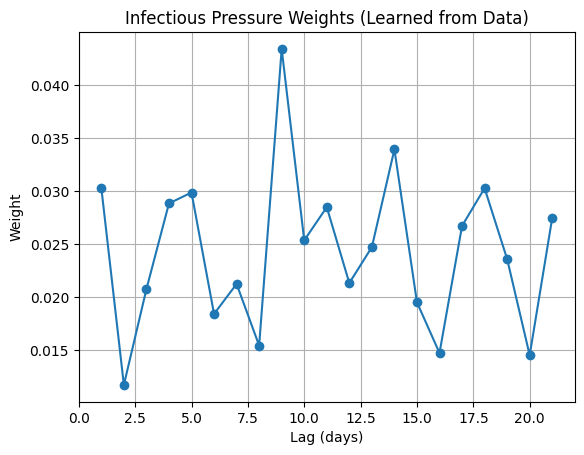

In [21]:
import matplotlib.pyplot as plt

# ip_weights already created earlier
# If not, recreate:
ip_weights = pd.DataFrame({
    "Lag": range(1, len(weights)+1),
    "Weight": weights
})

plt.figure()
plt.plot(ip_weights["Lag"], ip_weights["Weight"], marker='o')
plt.xlabel("Lag (days)")
plt.ylabel("Weight")
plt.title("Infectious Pressure Weights (Learned from Data)")
plt.grid()

plt.show()

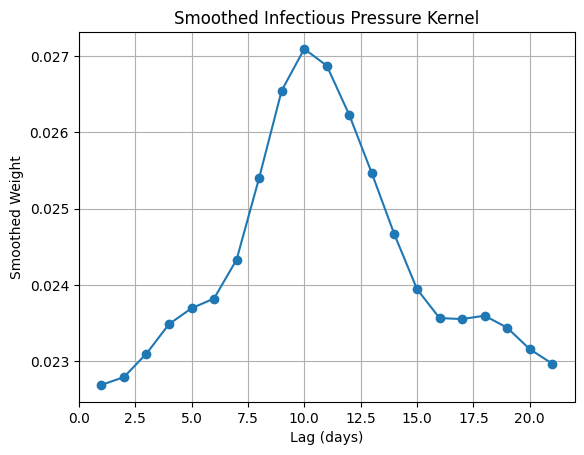

In [22]:
from scipy.ndimage import gaussian_filter1d

smoothed_weights = gaussian_filter1d(weights, sigma=2)

plt.figure()
plt.plot(range(1, len(weights)+1), smoothed_weights, marker='o')
plt.xlabel("Lag (days)")
plt.ylabel("Smoothed Weight")
plt.title("Smoothed Infectious Pressure Kernel")
plt.grid()

plt.show()